# Sanity check - fresh BigQuery pull

Data quality/cleanliness check on the latest fresh BigQuery pull (data/raw/eth_fresh_<start>_<end>.parquet,
auto-selected below by latest end date), before feeding it into soft labeling

This is NOT the same kind of EDA as 01_eda_bybit_historical.ipynb: this pull has no from_label/
to_label at all - there is no ground truth to analyze a fraud/non-fraud split against.
The only thing worth checking here is pipeline/data integrity: did the fetch produce what we expect,
and does it look like something the model trained on the historical set can meaningfully score.

52M rows / raw 8GB - too large to comfortably load whole into pandas heavy objects, so this notebook
queries the parquet file directly with DuckDB and only materializes already-aggregated results as DataFrames for plotting.

In [1]:
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(
    style="whitegrid",
    rc={"figure.figsize": (8, 4), "figure.dpi": 150},
)

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path().cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
FRESH_FILENAME_RE = re.compile(r"eth_fresh_(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})\.parquet$")

In [3]:
def find_latest_fresh_path(raw_dir: Path) -> Path:
    """Picks the eth_fresh_<start>_<end>.parquet file with the latest end date"""
    candidates = [
        (match.group(2), path)
        for path in raw_dir.glob("eth_fresh_*.parquet")
        if (match := FRESH_FILENAME_RE.search(path.name))
    ]
    if not candidates:
        raise FileNotFoundError(f"no eth_fresh_<start>_<end>.parquet files found in {raw_dir}")
    return max(candidates, key=lambda c: c[0])[1]

In [4]:
FRESH_PATH = find_latest_fresh_path(RAW_DATA_DIR)
print(f"using latest fresh pull: {FRESH_PATH.name}")

using latest fresh pull: eth_fresh_2026-09-14_2026-09-27.parquet


In [5]:
_window_match = FRESH_FILENAME_RE.search(FRESH_PATH.name)
WINDOW_START = pd.Timestamp(_window_match.group(1), tz="UTC")
WINDOW_END = pd.Timestamp(_window_match.group(2), tz="UTC") + pd.Timedelta(days=1)  # exclusive

HISTORICAL_RAW_PATH = PROJECT_ROOT / "data" / "raw" / "bybit_ec_all14days_Tx.parquet"
HISTORICAL_FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "bybit_address_features.parquet"
FRESH_CONTRACT_FLAGS_PATH = PROJECT_ROOT / "data" / "interim" / "eth_fresh_address_contract_flags.parquet"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

NULL_ADDRESSES = {
    "0x0000000000000000000000000000000000000000",
    "0x000000000000000000000000000000000000dead",
}

In [6]:
con = duckdb.connect()
fresh = lambda sql: con.execute(sql.format(path=str(FRESH_PATH))).df()

## Schema and scale

In [7]:
con.execute(f"DESCRIBE SELECT * FROM read_parquet('{FRESH_PATH}')").df()

,column_name,column_type,null,key,default,extra
0,hash,VARCHAR,YES,None,None,None
1,from,VARCHAR,YES,None,None,None
2,to,VARCHAR,YES,None,None,None
3,value,DOUBLE,YES,None,None,None
4,timeStamp,BIGINT,YES,None,None,None
5,contractAddress,VARCHAR,YES,None,None,None
6,tokenSymbol,VARCHAR,YES,None,None,None
7,tokenDecimal,BIGINT,YES,None,None,None
8,gasPrice,BIGINT,YES,None,None,None
9,gasUsed,BIGINT,YES,None,None,None


In [8]:
n_rows = con.execute(f"SELECT COUNT(*) FROM read_parquet('{FRESH_PATH}')").fetchone()[0]
print(f"{n_rows:,} rows")

51,641,382 rows


***
Schema matches the historical dataset's columns exactly, minus from_label/to_label/tx_label. No schema drift to fix before the "scoring mode"
adapter can run
***

## Window integrity

Requested window was covered 14 days. Any timestamp outside [WINDOW_START, WINDOW_END) would mean the BQ query's range filter didn't do what we think it did.

In [9]:
ts_bounds = con.execute(
    f"SELECT MIN(timeStamp), MAX(timeStamp), COUNT(*) FILTER (WHERE timeStamp < {int(WINDOW_START.timestamp())} "
    f"OR timeStamp >= {int(WINDOW_END.timestamp())}) FROM read_parquet('{FRESH_PATH}')"
).fetchone()
min_ts, max_ts, n_outside = ts_bounds
print(f"min: {pd.to_datetime(min_ts, unit='s', utc=True)}")
print(f"max: {pd.to_datetime(max_ts, unit='s', utc=True)}")
print(f"rows outside requested window: {n_outside} ({n_outside / n_rows:.2%})")

min: 2026-09-14 00:00:11+00:00
max: 2026-09-27 23:59:59+00:00
rows outside requested window: 0 (0.00%)


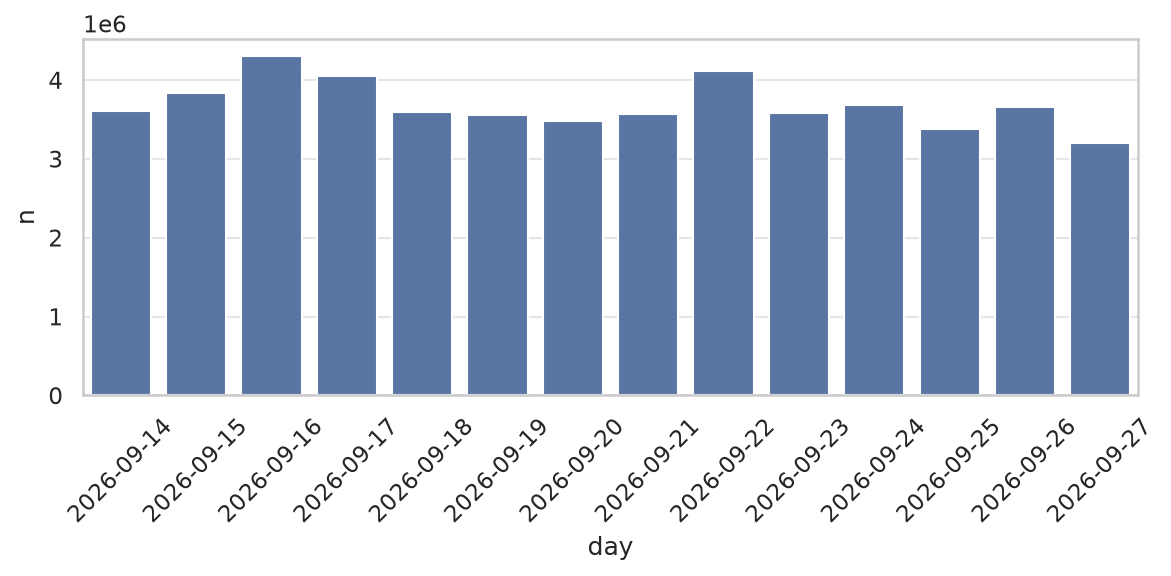

In [10]:
daily_counts = con.execute(
    f"""
    SELECT CAST(to_timestamp(timeStamp) AT TIME ZONE 'UTC' AS DATE) AS day, COUNT(*) AS n
    FROM read_parquet('{FRESH_PATH}')
    GROUP BY day ORDER BY day
    """
).df()
fig, ax = plt.subplots()
sns.barplot(data=daily_counts, x="day", y="n", ax=ax)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Nulls per column

In [11]:
columns = [c for c in fresh("SELECT * FROM read_parquet('{path}') LIMIT 0").columns]
null_counts = con.execute(
    f"""
    SELECT {', '.join(f"COUNT(*) FILTER (WHERE \"{c}\" IS NULL) AS {c}" for c in columns)}
    FROM read_parquet('{FRESH_PATH}')
    """
).df().T.rename(columns={0: "null_count"})
null_counts["null_share"] = null_counts["null_count"] / n_rows

In [12]:
print(null_counts)

                 null_count  null_share
hash                      0    0.000000
from                      0    0.000000
to                        0    0.000000
value                     0    0.000000
timeStamp                 0    0.000000
contractAddress           0    0.000000
tokenSymbol          246082    0.004765
tokenDecimal              0    0.000000
gasPrice                  0    0.000000
gasUsed                   0    0.000000
gasFee                    0    0.000000


## Exact duplicate rows

In [13]:
n_distinct = con.execute(f"SELECT COUNT(*) FROM (SELECT DISTINCT * FROM read_parquet('{FRESH_PATH}'))").fetchone()[0]
print(f"exact duplicate rows: {n_rows - n_distinct} ({(n_rows - n_distinct) / n_rows:.4%})")

exact duplicate rows: 1988547 (3.8507%)


***
Rows were streamed to parquet chunk-by-chunk - a duplicate chunk would indicate
a retry bug in run_fetch. That's one candidate explanation - a JOIN fan-out in FETCH_SQL is another.
Diagnosing which one it actually is before deciding how to handle it - "drop duplicates" is the wrong fix if these are
genuinely distinct on-chain events that only look identical under our column selection.
***

### Diagnosis: multiplicity distribution

If this were a JOIN fan-out (eg. tokens.address matching >1 row in the tokens table), we'd
expect a mostly-uniform small multiplier (2x, maybe 3x) spread broadly across many transactions.
A retry bug in the streaming writer would duplicate whole chunks - contiguous ranges of otherwise
unremarkable rows.

In [14]:
multiplicity = con.execute(
    f"""
    WITH dup_groups AS (
        SELECT COUNT(*) AS n FROM read_parquet('{FRESH_PATH}')
        GROUP BY hash, "from", "to", value, timeStamp, contractAddress, tokenSymbol, tokenDecimal,
                 gasPrice, gasUsed, gasFee
    )
    SELECT n AS multiplicity, COUNT(*) AS n_groups FROM dup_groups GROUP BY n ORDER BY n
    """
).df()
print(f"max multiplicity observed: {multiplicity['multiplicity'].max()}")

max multiplicity observed: 548


In [15]:
print(multiplicity.tail(10))

     multiplicity  n_groups
141           198         2
142           199      1800
143           200      4124
144           207         1
145           209         1
146           218         1
147           247         3
148           272         1
149           298         1
150           548         1


***
Not a uniform 2x/3x fan-out - there's a long tail up to multiplicities in the hundreds. That
already argues against a simple JOIN fan-out and points toward something concentrated in a small
number of specific transactions.
***

In [16]:
hash_clustering = con.execute(
    f"""
    WITH dup_groups AS (
        SELECT hash, COUNT(*) AS n
        FROM read_parquet('{FRESH_PATH}')
        GROUP BY hash, "from", "to", value, timeStamp, contractAddress, tokenSymbol, tokenDecimal,
                 gasPrice, gasUsed, gasFee
        HAVING COUNT(*) > 1
    )
    SELECT COUNT(DISTINCT hash) AS distinct_hashes_involved, COUNT(*) AS dup_groups, SUM(n) AS total_dup_rows
    FROM dup_groups
    """
).df()

In [17]:
print(hash_clustering)

   distinct_hashes_involved  dup_groups  total_dup_rows
0                     50697      107202       2095749.0


***
107k duplicate-signature groups concentrated in only 50k distinct transactions - confirms
clustering by transaction. Which token contracts are these transactions moving?
***

In [18]:
top_dup_contracts = con.execute(
    f"""
    WITH dup_groups AS (
        SELECT hash, contractAddress, any_value(tokenSymbol) AS symbol, COUNT(*) AS n
        FROM read_parquet('{FRESH_PATH}')
        GROUP BY hash, "from", "to", value, timeStamp, contractAddress, tokenSymbol, tokenDecimal,
                 gasPrice, gasUsed, gasFee
        HAVING COUNT(*) > 1
    )
    SELECT contractAddress, symbol, COUNT(*) AS n_dup_groups, SUM(n) AS total_rows
    FROM dup_groups GROUP BY contractAddress, symbol ORDER BY total_rows DESC LIMIT 10
    """
).df()
top_dup_contracts["share_of_all_dup_rows"] = top_dup_contracts["total_rows"] / hash_clustering["total_dup_rows"].iloc[0]

In [19]:
print(top_dup_contracts)

                              contractAddress  symbol  n_dup_groups  \
0  0x5fa54fddf1870c344dbfabb37dfab8700ec0def1  FROGEX          5748   
1  0x06450dee7fd2fb8e39061434babcfc05599a6fb8     XEN         16157   
2  0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2    WETH         14262   
3  0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48    USDC          9322   
4  0xdac17f958d2ee523a2206206994597c13d831ec7    USDT          5572   
5  0x2260fac5e5542a773aa44fbcfedf7c193bc2c599    WBTC          1420   
6  0xd81a8b5be59ceae0f9e27455a998b4fdac9fa0a3    ENSU           177   
7  0xd4fa1460f537bb9085d22c7bccb5dd450ef28e3a     PPT           873   
8  0x4e3fbd56cd56c3e72c1403e103b45db9da5b9d2b     CVX          1086   
9  0x6b175474e89094c44da98b954eedeac495271d0f     DAI          1318   

   total_rows  share_of_all_dup_rows  
0   1147804.0               0.547682  
1    697700.0               0.332912  
2     55017.0               0.026252  
3     20652.0               0.009854  
4     11823.0          

***
Two tokens: FROGEX and XEN - account for nearly 90% of all duplicate group rows. Both are XEN Crypto
and XEN-style forks: contracts whose mint/claim function is designed to be called in a loop
within a single transaction, each iteration emitting its own, distinct Transfer event with identical (from, to, value). Let's look at one concrete transaction to confirm.
***

In [20]:
max_multiplicity = int(multiplicity["multiplicity"].max())
extreme_hash = con.execute(
    f"""
    SELECT hash FROM (
        SELECT hash, COUNT(*) AS n FROM read_parquet('{FRESH_PATH}')
        GROUP BY hash, "from", "to", value, timeStamp, contractAddress, tokenSymbol, tokenDecimal,
                 gasPrice, gasUsed, gasFee
    ) WHERE n = {max_multiplicity}
    """
).fetchone()[0]

anatomy = con.execute(
    f"""
    SELECT "from", "to", value, contractAddress, COUNT(*) AS n
    FROM read_parquet('{FRESH_PATH}')
    WHERE hash = '{extreme_hash}'
    GROUP BY "from", "to", value, contractAddress
    ORDER BY n DESC
    """
).df()
total_for_hash = con.execute(f"SELECT COUNT(*) FROM read_parquet('{FRESH_PATH}') WHERE hash = '{extreme_hash}'").fetchone()[0]
print(f"hash {extreme_hash}: {total_for_hash} total transfer rows")
anatomy

hash 0xad2b450a3eb05f8dee0faf7e3fc09e1073b0b9655758c6737cf88281d3ee1322: 608 total transfer rows


,from,to,value,contractAddress,n
0,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,0xbf424ee12ba52b5cdffd6d83b1033fe51c8b2435,1.0,0x41dd36ef50f565aa89f41fde7376c44e3a93dd75,548
1,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,0xbf424ee12ba52b5cdffd6d83b1033fe51c8b2435,1.0,0x9eb71a43ebebbfc1c9a7bc65a6e375590879d56e,53
2,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,0x30cc36add01329d2b57a1d01f93c69a3ef88457d,1.0,0x0f95bb1f2ea7e4cc29d65bcc42190104d82d5f94,4
3,0xbf424ee12ba52b5cdffd6d83b1033fe51c8b2435,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,600.0,0x41dd36ef50f565aa89f41fde7376c44e3a93dd75,1
4,0x30cc36add01329d2b57a1d01f93c69a3ef88457d,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,600.0,0x0f95bb1f2ea7e4cc29d65bcc42190104d82d5f94,1
5,0xbf424ee12ba52b5cdffd6d83b1033fe51c8b2435,0x7af0404c57b13da6befa91ad26df5b1c0a58e50d,600.0,0x9eb71a43ebebbfc1c9a7bc65a6e375590879d56e,1


***
A single transaction with 608 transfer rows, of which one (from, to, value, contractAddress)
combination repeats 548 times. transaction_hash alone doesn't uniquely identify a transfer row
in token_transfers - log_index does, and FETCH_SQL (src/data/bq_fetch_day.py) never selected
it. These 548 rows are 548 real, distinct on-chain events (one per mint-loop iteration) - they
only look like exact duplicates because our schema can't tell them apart.
***

For contrast: is the historical dataset affected by the same issue?

In [21]:
hist_total = con.execute(f"SELECT COUNT(*) FROM read_parquet('{HISTORICAL_RAW_PATH}')").fetchone()[0]
hist_distinct = con.execute(
    f"""
    SELECT COUNT(*) FROM (
        SELECT DISTINCT hash, "from", "to", value, timeStamp, contractAddress, tokenSymbol,
               tokenDecimal, gasPrice, gasUsed, gasFee
        FROM read_parquet('{HISTORICAL_RAW_PATH}')
    )
    """
).fetchone()[0]
print(f"historical dataset duplicate share: {(hist_total - hist_distinct) / hist_total:.4%}")

historical dataset duplicate share: 0.0000%


### Conclusion and decision

**Historical dataset case**: The historical training dataset has zero such duplicates, so the already trained ensemble is unaffected and doesn't need retraining over this.

**Fresh dataset case**: left as-is, addresses that farm XEN/FROGEX would
get artificially inflated out_degree / tx_per_active_day / gas aggregates purely from one
gas-optimized batch call which could produce a spuriously high risk score unrelated to money laundering

**Decision**: re-fetching with log_index added isn't worth the BQ cost for two tokens that are
thematically irrelevant to AML risk scoring anyway. Instead deduplicate on full-row identity
before any feature computation, and document the known cause (batch-mint contracts) as an accepted,
deliberate simplification. All analysis below this point uses fresh_deduped, not the raw file.

In [22]:
con.execute(f"CREATE OR REPLACE TABLE fresh_deduped AS SELECT DISTINCT * FROM read_parquet('{FRESH_PATH}')")
n_rows_deduped = con.execute("SELECT COUNT(*) FROM fresh_deduped").fetchone()[0]
print(f"{n_rows_deduped:,} rows after dedup ({n_rows - n_rows_deduped:,} dropped)")

49,652,835 rows after dedup (1,988,547 dropped)


***
Materialized as a table, instead of a view: a view would re-run this whole distinct-over-52M-rows scan
from the raw parquet on every single reference below, instead of once.
***

## Address format consistency

build_features.py's NULL_ADDRESSES set and the join against data/interim/bybit_address_contract_flags.parquet
both assume lowercase hex addresses (BigQuery's convention). A casing mismatch here would silently
break both the mint/burn split and the is_contract join.

In [23]:
casing = con.execute(
    f"""
    SELECT
        COUNT(*) FILTER (WHERE "from" != lower("from") OR "to" != lower("to")) AS mixed_case_rows,
        COUNT(*) FILTER (WHERE NOT regexp_matches("from", '^0x[0-9a-f]{{40}}$')) AS malformed_from,
        COUNT(*) FILTER (WHERE NOT regexp_matches("to", '^0x[0-9a-f]{{40}}$')) AS malformed_to
    FROM fresh_deduped
    """
).df()

In [24]:
print(casing)

   mixed_case_rows  malformed_from  malformed_to
0                0               0             0


## Mint/burn exposure

In [25]:
mint_burn_share = {}
for label, path in [("fresh", FRESH_PATH), ("historical", HISTORICAL_RAW_PATH)]:
    total, mint_burn = con.execute(
        f"""
        SELECT COUNT(*),
               COUNT(*) FILTER (WHERE "from" IN {tuple(NULL_ADDRESSES)} OR "to" IN {tuple(NULL_ADDRESSES)})
        FROM read_parquet('{path}')
        """
    ).fetchone()
    mint_burn_share[label] = mint_burn / total
    print(f"{label}: {mint_burn / total:.2%} mint/burn rows ({mint_burn:,} / {total:,})")

fresh: 6.42% mint/burn rows (3,315,577 / 51,641,382)
historical: 6.73% mint/burn rows (176,102 / 2,616,736)


## Token concentration

Checks whether a handful of contracts dominate row volume - relevant because value_zscore in
build_features.py is computed per contractAddress - a contract with too few background rows falls
back to the whole-population reference.

In [26]:
n_distinct_tokens = con.execute("SELECT COUNT(DISTINCT contractAddress) FROM fresh_deduped").fetchone()[0]
print(f"{n_distinct_tokens:,} distinct token contracts")

60,007 distinct token contracts


In [27]:
top_tokens = con.execute(
    f"""
    SELECT contractAddress, any_value(tokenSymbol) AS symbol, COUNT(*) AS n_rows, COUNT(*) / {n_rows_deduped}.0 AS share
    FROM fresh_deduped
    GROUP BY contractAddress ORDER BY n_rows DESC LIMIT 15
    """
).df()
top_tokens

,contractAddress,symbol,n_rows,share
0,0xdac17f958d2ee523a2206206994597c13d831ec7,USDT,9749660,0.196357
1,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,USDC,8621449,0.173635
2,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,WETH,4025669,0.081076
3,0xbeef007ecfbfdf9b919d0050821a9b6dbd634ff0,techblockEURCV,1292603,0.026033
4,0x06450dee7fd2fb8e39061434babcfc05599a6fb8,XEN,719214,0.014485
5,0x014d7f8699ffaef3042fac8e59b03beb464dcbeb,꒤5DT,627823,0.012644
6,0x2260fac5e5542a773aa44fbcfedf7c193bc2c599,WBTC,455857,0.009181
7,0x08dfd4651f1985d44aebc5a616c757c2373c8172,꒤5DT,394767,0.007951
8,0x87f915a9da7267809e512c0c4b5602fd4b595f9e,U5឴឴Dꓔ,391287,0.007880
9,0x9271cd94e47483eb20dc00fb92a098aa540f82ba,꒤5DC,391010,0.007875


## Value sanity

In [28]:
value_stats = con.execute(
    f"""
    SELECT
        COUNT(*) FILTER (WHERE value < 0) AS negative,
        COUNT(*) FILTER (WHERE value = 0) AS zero,
        COUNT(*) FILTER (WHERE value IS NULL) AS null_value,
        quantile_cont(value, [0.5, 0.9, 0.99, 0.999]) AS quantiles
    FROM fresh_deduped
    WHERE value >= 0
    """
).df()
value_stats

,negative,zero,null_value,quantiles
0,0,2565881,0,"[50.0, 32899.0, 42576629.014281765, 2610820100..."


## Gas sanity

gasFee was computed in bq_fetch_day.py SQL as (gasPrice * gasUsed) / 1e18 - checking here that nothing produced negative/absurd values.

In [29]:
gas_stats = con.execute(
    f"""
    SELECT
        COUNT(*) FILTER (WHERE gasPrice <= 0) AS non_positive_gas_price,
        COUNT(*) FILTER (WHERE gasUsed <= 0) AS non_positive_gas_used,
        COUNT(*) FILTER (WHERE gasFee <= 0) AS non_positive_gas_fee,
        quantile_cont(gasFee, [0.5, 0.9, 0.99, 0.999]) AS gas_fee_quantiles
    FROM fresh_deduped
    """
).df()
gas_stats

,non_positive_gas_price,non_positive_gas_used,non_positive_gas_fee,gas_fee_quantiles
0,0,0,0,"[0.000119335762114992, 0.000869547676375719, 0..."


## Address persistence: historical labeled addresses in fresh data

How many addresses labeled in the ByBit hack investigation (~1.5 years ago) are still active in
this fresh 14-day window?

In [30]:
con.execute(
    f"""
    CREATE OR REPLACE TABLE fresh_addresses AS
    SELECT DISTINCT address FROM (
        SELECT "from" AS address FROM fresh_deduped
        UNION ALL
        SELECT "to" AS address FROM fresh_deduped
    )
    WHERE address NOT IN {tuple(NULL_ADDRESSES)}
    """
)
n_fresh_addresses = con.execute("SELECT COUNT(*) FROM fresh_addresses").fetchone()[0]
print(f"{n_fresh_addresses:,} distinct addresses in fresh data")

8,225,793 distinct addresses in fresh data


In [31]:
historical_labels = pd.read_parquet(HISTORICAL_FEATURES_PATH, columns=["label"])
historical_labels.index.name = "address"
historical_labels = historical_labels.reset_index()
con.register("historical_labels", historical_labels)

overlap = con.execute(
    """
    SELECT hl.label, COUNT(*) AS n_labeled, COUNT(fa.address) AS n_overlap
    FROM historical_labels hl
    LEFT JOIN fresh_addresses fa ON fa.address = hl.address
    GROUP BY hl.label
    """
).df()
overlap["overlap_share"] = overlap["n_overlap"] / overlap["n_labeled"]
print(overlap)

   label  n_labeled  n_overlap  overlap_share
0    0.0      34050         54       0.001586
1    1.0      12000          1       0.000083


## is_contract coverage for fresh addresses

In [32]:
fresh_contract_flags = pd.read_parquet(FRESH_CONTRACT_FLAGS_PATH)
con.register("fresh_contract_flags", fresh_contract_flags)

con.execute(
    """
    CREATE OR REPLACE TABLE fresh_eoa_addresses AS
    SELECT fa.address
    FROM fresh_addresses fa
    LEFT JOIN fresh_contract_flags cf ON cf.address = fa.address
    WHERE COALESCE(cf.is_contract, false) = false
    """
)

coverage = con.execute(
    """
    SELECT
        COUNT(*) AS n_fresh_addresses,
        COUNT(cf.address) AS n_covered,
        COUNT(*) FILTER (WHERE cf.is_contract) AS n_contracts,
        (SELECT COUNT(*) FROM fresh_eoa_addresses) AS n_eoa
    FROM fresh_addresses fa
    LEFT JOIN fresh_contract_flags cf ON cf.address = fa.address
    """
).df()
coverage["coverage_share"] = coverage["n_covered"] / coverage["n_fresh_addresses"]
coverage["contract_share"] = coverage["n_contracts"] / coverage["n_fresh_addresses"]
print(coverage)

   n_fresh_addresses  n_covered  n_contracts    n_eoa  coverage_share  \
0            8225793    8225793      1005320  7220473             1.0   

   contract_share  
0        0.122216  


***
~12% of the fresh population are contracts (routers/pools/tokens) - the historical training
set is already EOA-only (feature constructor filters contracts before saving), so the
feature-space comparison below must exclude them from the fresh side too.
***

## Feature-space overlap vs the historical training set

In [33]:
historical_features = pd.read_parquet(
    HISTORICAL_FEATURES_PATH,
    columns=["out_degree", "in_degree", "gas_used_mean"],
)

fresh_degree = con.execute(
    f"""
    WITH graph AS (
        SELECT fd.* FROM fresh_deduped fd
        JOIN fresh_eoa_addresses ea ON ea.address = fd."from"
        WHERE fd."to" NOT IN {tuple(NULL_ADDRESSES)}
    )
    SELECT "from" AS address, COUNT(*) AS out_degree FROM graph GROUP BY "from"
    """
).df()

fresh_gas = con.execute(
    f"""
    WITH graph AS (
        SELECT fd.* FROM fresh_deduped fd
        JOIN fresh_eoa_addresses ea ON ea.address = fd."from"
        WHERE fd."to" NOT IN {tuple(NULL_ADDRESSES)}
    ), tx_level AS (
        SELECT DISTINCT "from" AS address, hash, gasUsed FROM graph
    )
    SELECT address, AVG(gasUsed) AS gas_used_mean FROM tx_level GROUP BY address
    """
).df()

In [34]:
comparisons = {
    "out_degree": (fresh_degree["out_degree"], historical_features["out_degree"]),
    "gas_used_mean": (fresh_gas["gas_used_mean"], historical_features["gas_used_mean"].dropna())
}
for name, (fresh_series, historical_series) in comparisons.items():
    print(f"{name} quantiles (fresh vs historical training set):")
    print(pd.concat(
        {"fresh": fresh_series.quantile([0.5, 0.9, 0.99, 0.999]), "historical": historical_series.quantile([0.5, 0.9, 0.99, 0.999])},
        axis=1,
    ))
    print()

out_degree quantiles (fresh vs historical training set):
       fresh  historical
0.500    1.0       0.000
0.900   12.0       3.000
0.990   73.0     116.510
0.999  378.0     427.559

gas_used_mean quantiles (fresh vs historical training set):
            fresh    historical
0.500   161060.30  3.001450e+04
0.900  3473380.25  7.885834e+05
0.990  5196779.00  1.703592e+06
0.999  6923044.00  1.985875e+06



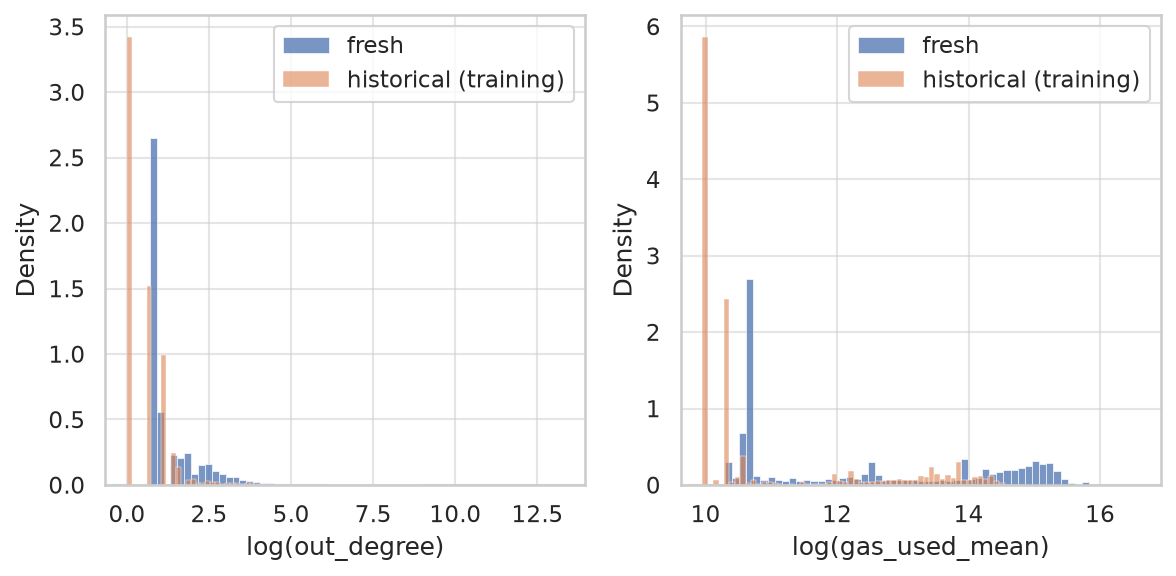

In [35]:
fig, axes = plt.subplots(1, 2)
for ax, (name, (fresh_series, historical_series)) in zip(axes, comparisons.items()):
    fresh_plot = np.log1p(fresh_series)
    historical_plot = np.log1p(historical_series)
    sns.histplot(fresh_plot, bins=60, stat="density", ax=ax, label="fresh", color="C0")
    sns.histplot(historical_plot, bins=60, stat="density", ax=ax, label="historical (training)", color="C1", alpha=0.6)
    ax.set_xlabel(f"log({name})")
    ax.legend()
plt.tight_layout()
plt.show()

***
This figure traces back to label composition, rather than a general property of Ethereum addresses:
label=0 addresses are 74% of the population and about 68% of them have out_degree == 0 - they are overwhelmingly one-off, passive recipients caught up in the ByBit trace (victims, incidental counterparties).
label=1 addresses are the opposite: only 1.3% have out_degree == 0, since actively laundering funds
means sending them onward almost by definition.

Worth keeping in mind when interpreting
any fresh-vs-historical comparison: the historical "clean" population is not a stand-in for typical EOA behavior in general.
***